# ERA5-Land-Based 35-Year Climatology by Cluster

A 35-year (1988–2022) climatology of ERA5-Land variables was constructed to investigate the delayed melt timing observed in Cluster 1 relative to other clusters.

To provide an independent assessment from passive microwave satellite data, we analyzed cluster-wise climatologies of near-surface air temperature and snow-related variables derived from ERA5-Land. This approach enables a physically consistent interpretation of the environmental conditions associated with each cluster.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pdL
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from arch.bootstrap import MovingBlockBootstrap

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Define functions

In [2]:
def is_leap_year(year):
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)

def days_in_year(year):
    return 366 if is_leap_year(year) else 365

def get_peak_doy_and_value(arr): # Function to get the peak DOY and value
    if np.all(np.isnan(arr)):
        return np.nan, np.nan
    peak_idx = np.nanargmax(arr)   # 0-based index
    peak_doy = peak_idx + 1        # convert to DOY
    peak_val = arr[peak_idx]
    return peak_doy, peak_val

def get_zero_doy_and_value(arr): # Function to get the zero DOY and value
    if np.all(np.isnan(arr)):
        return np.nan, np.nan
    zero_idx = np.nanargmin(arr)   # 0-based index
    zero_doy = zero_idx + 1        # convert to DOY
    zero_val = arr[zero_idx]
    return zero_doy, zero_val

## Cluster-wise 35-Year Climatology of ERA5-Land Snow-Related Variables

This code plots the 35-year (1988–2022) climatologies of ERA5-Land snow-related variables, including snow water equivalent (SWE), snow depth, and snow cover, for each TB-based cluster.

To focus on regions characterized by seasonal snow, only pixels with near-zero summer SWE were retained. Specifically, for each year, pixels with a mean SWE below 0.01 m of water equivalent during the common summer period (approximately DOY 200–230) were classified as seasonal-snow pixels and used to compute the cluster-wise climatologies.

Although permafrost regions were already excluded during the construction of the TB-difference-based clusters, this additional filtering was applied as a precaution. As a result, more than 90% of pixels were retained across all clusters, indicating that the analysis remains representative of the original cluster distributions.

### Supplementary Figure 1

=== Seasonal-mask impact (per cluster) ===
Cluster 0: base pixels = 14288
  kept pixels (mean ± std over years): 13045 ± 23
  kept fraction (mean ± std): 91.3% ± 0.2%
  union seasonal fraction (any year): 91.5%
Cluster 1: base pixels = 11975
  kept pixels (mean ± std over years): 11290 ± 31
  kept fraction (mean ± std): 94.3% ± 0.3%
  union seasonal fraction (any year): 94.4%
Cluster 2: base pixels = 13848
  kept pixels (mean ± std over years): 13675 ± 47
  kept fraction (mean ± std): 98.8% ± 0.3%
  union seasonal fraction (any year): 98.9%

=== Peak DOY from 35-year mean climatology ===

Cluster 0
  SWE  peak: DOY 95, value = 0.1829
  SD   peak: DOY 60, value = 0.7318
  Snow cover peak: DOY 46, value = 97.7778
  SWE  zero: DOY 213, value = 0.0000
  SD   zero: DOY 207, value = 0.0001
  Snow cover zero: DOY 207, value = 0.0989

Cluster 1
  SWE  peak: DOY 117, value = 0.1553
  SD   peak: DOY 75, value = 0.7346
  Snow cover peak: DOY 66, value = 97.2280
  SWE  zero: DOY 208, value = 0.000

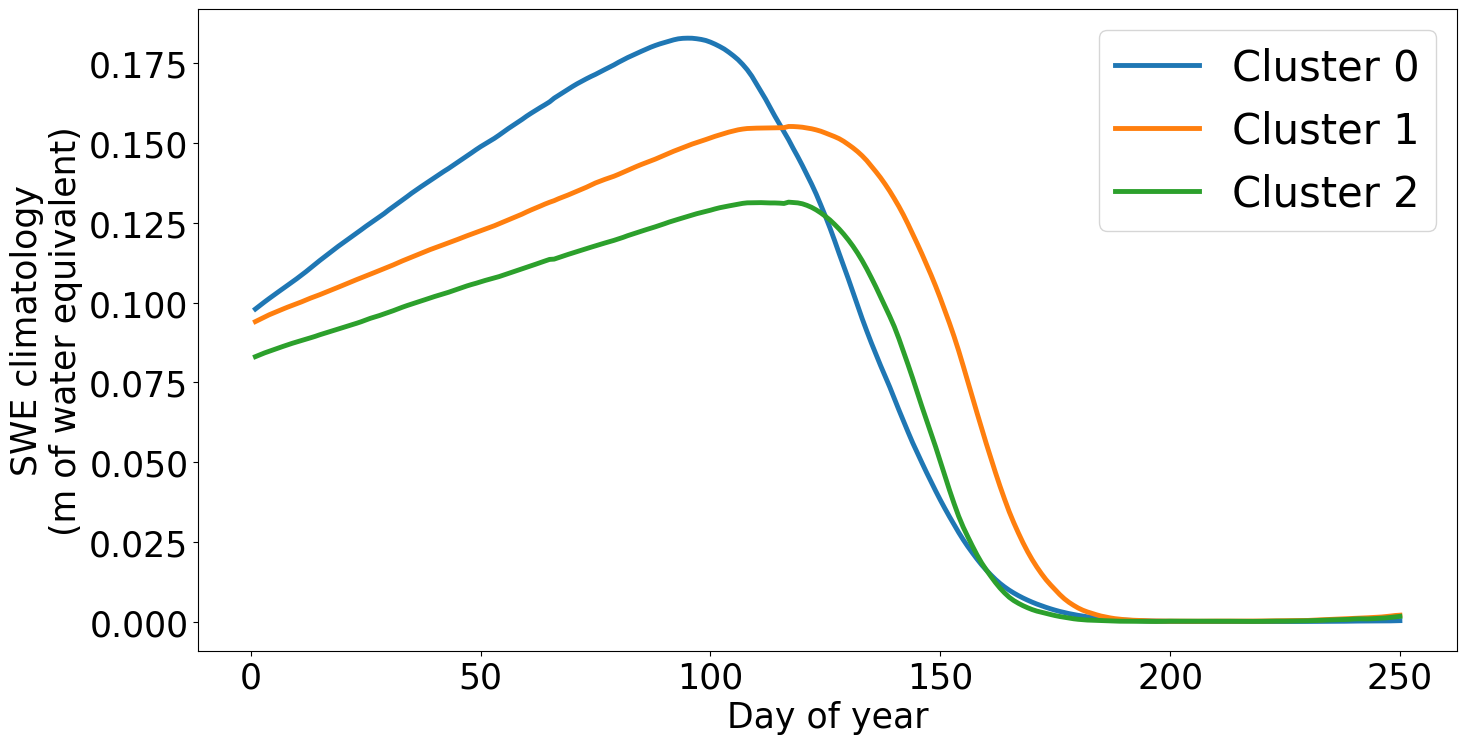

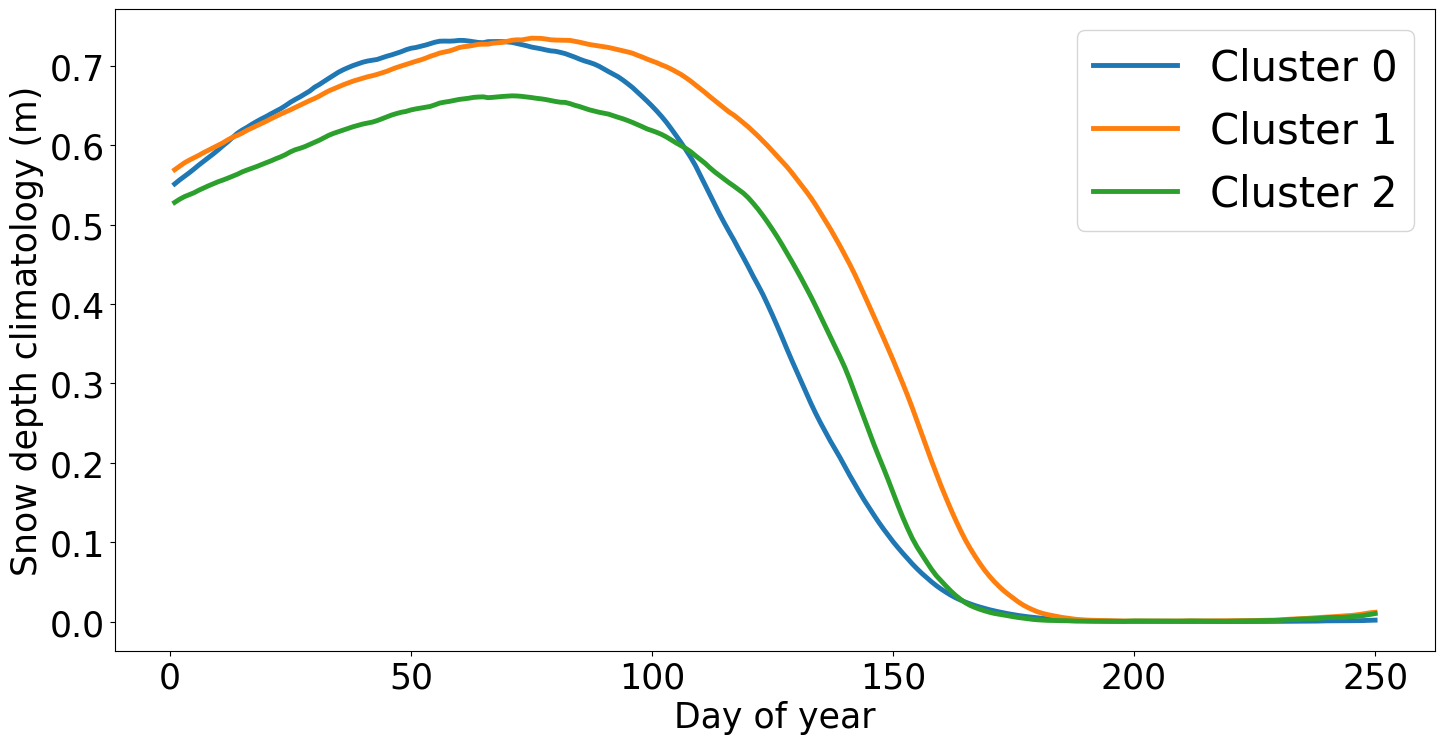

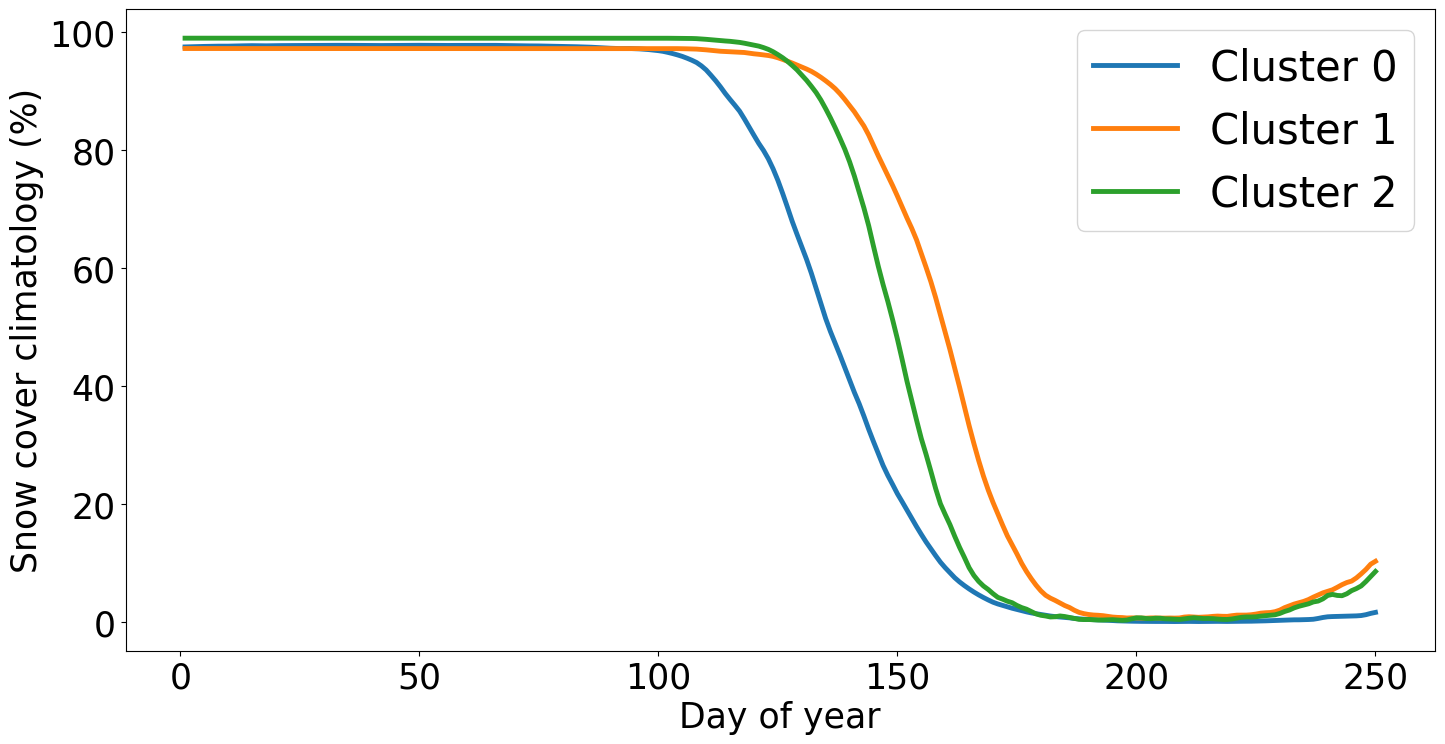

In [3]:
out_dir = "/home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land"

# Define the period
start_year, end_year = 1988, 2022
years = np.arange(start_year, end_year + 1)
ndoy = 250

# Define paths
Daily_ERA5_path = f"{data2_FP}/ERA5_Land/extracted_nc/Above_60N/Revised_ERA5_25km_60N"
TB_cluster_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc"

# 1. Load cluster map
with nc.Dataset(TB_cluster_path) as ds:
    TB_cluster = ds.variables["TB_cluster"][:]
TB_cluster = TB_cluster.astype(int)

cluster_ids = [0, 1, 2]
base_counts = {cid: int(np.sum(TB_cluster == cid)) for cid in cluster_ids}


# 2. Create the storage for climatologies
clim_swe = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}
clim_sd  = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}
clim_snowcover = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}

# Diagnostics: per-year kept pixel counts and fractions (after seasonal_mask)
mask_counts = {cid: [] for cid in cluster_ids}
mask_fracs  = {cid: [] for cid in cluster_ids}

# Union seasonal mask (True if seasonal_mask True in ANY year)
seasonal_union = np.zeros_like(TB_cluster, dtype=bool)

# Precompute cluster masks
cluster_masks = {cid: (TB_cluster == cid) for cid in cluster_ids}


# 3. Loop over years
for yi, year in enumerate(years):
    path = f"{Daily_ERA5_path}/ERA5_Land_Daily_Above_60N_{year}.nc"
    with nc.Dataset(path) as ds:
        SWE = ds.variables["sd_mean"][:, :, :ndoy]   # SWE (m of water equivalent)  (lat, lon, doy)
        SD  = ds.variables["sde_mean"][:, :, :ndoy]  # snow depth (m) (lat, lon, doy)
        SnowCover = ds.variables["snowc_mean"][:, :, :ndoy] # snow cover (mm/day) (lat, lon, doy)

    # Seasonal snow mask: keep pixels with near-zero summer SWE
    # DOY 200–230 -> indices 199:230
    summer_mean_swe = np.nanmean(SWE[:, :, 199:230], axis=2)
    seasonal_mask = (summer_mean_swe < 0.01)  # 0.01 m w.e. = 10 mm

    # Update union mask
    seasonal_union |= seasonal_mask

    # Diagnostics: how many pixels kept per cluster in this year?
    for cid in cluster_ids:
        base = cluster_masks[cid]
        n_base = base_counts[cid]
        n_keep = int(np.sum(base & seasonal_mask))
        mask_counts[cid].append(n_keep)
        mask_fracs[cid].append(n_keep / n_base if n_base > 0 else np.nan)

    # Compute per-DOY spatial means within each cluster (with seasonal mask)
    for d in range(ndoy):
        swe_d = SWE[:, :, d]
        sd_d  = SD[:, :, d]
        snowcover_d = SnowCover[:, :, d]
        for cid in cluster_ids:
            m = cluster_masks[cid] & seasonal_mask
            if np.any(m):
                clim_swe[cid][yi, d] = np.nanmean(swe_d[m])
                clim_sd[cid][yi, d]  = np.nanmean(sd_d[m])
                clim_snowcover[cid][yi, d] = np.nanmean(snowcover_d[m])
            else:
                clim_swe[cid][yi, d] = np.nan
                clim_sd[cid][yi, d]  = np.nan
                clim_snowcover[cid][yi, d] = np.nan


# 4. Summaries
print("=== Seasonal-mask impact (per cluster) ===")
for cid in cluster_ids:
    print(f"Cluster {cid}: base pixels = {base_counts[cid]}")
    print(f"  kept pixels (mean ± std over years): "
          f"{np.mean(mask_counts[cid]):.0f} ± {np.std(mask_counts[cid]):.0f}")
    print(f"  kept fraction (mean ± std): "
          f"{np.mean(mask_fracs[cid])*100:.1f}% ± {np.std(mask_fracs[cid])*100:.1f}%")
    print(f"  union seasonal fraction (any year): "
          f"{np.mean(seasonal_union[cluster_masks[cid]])*100:.1f}%")


# 35-year mean climatologies
clim_swe_mean = {cid: np.nanmean(clim_swe[cid], axis=0) for cid in cluster_ids}
clim_sd_mean  = {cid: np.nanmean(clim_sd[cid], axis=0) for cid in cluster_ids}
clim_snowcover_mean = {cid: np.nanmean(clim_snowcover[cid], axis=0) for cid in cluster_ids}


# Print Peak DOY and peak value
print("\n=== Peak DOY from 35-year mean climatology ===")
for cid in cluster_ids:
    swe_peak_doy, swe_peak_val = get_peak_doy_and_value(clim_swe_mean[cid])
    sd_peak_doy, sd_peak_val = get_peak_doy_and_value(clim_sd_mean[cid])
    snowcover_peak_doy, snowcover_peak_val = get_peak_doy_and_value(clim_snowcover_mean[cid])

    print(f"\nCluster {cid}")
    print(f"  SWE  peak: DOY {swe_peak_doy}, value = {swe_peak_val:.4f}")
    print(f"  SD   peak: DOY {sd_peak_doy}, value = {sd_peak_val:.4f}")
    print(f"  Snow cover peak: DOY {snowcover_peak_doy}, value = {snowcover_peak_val:.4f}")

    swe_zero_doy, swe_zero_val = get_zero_doy_and_value(clim_swe_mean[cid])
    sd_zero_doy, sd_zero_val = get_zero_doy_and_value(clim_sd_mean[cid])
    snowcover_zero_doy, snowcover_zero_val = get_zero_doy_and_value(clim_snowcover_mean[cid])

    print(f"  SWE  zero: DOY {swe_zero_doy}, value = {swe_zero_val:.4f}")
    print(f"  SD   zero: DOY {sd_zero_doy}, value = {sd_zero_val:.4f}")
    print(f"  Snow cover zero: DOY {snowcover_zero_doy}, value = {snowcover_zero_val:.4f}")

# Plot
doys = np.arange(1, ndoy + 1)
plt.rcParams.update({
    'font.size': 25,        
    'axes.titlesize': 30,     
    'axes.labelsize': 25,     
    'xtick.labelsize': 25,   
    'ytick.labelsize': 25,    
    'legend.fontsize': 30     
})

plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_swe_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("SWE climatology\n(m of water equivalent)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "SWE_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_sd_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("Snow depth climatology (m)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Snowdepth_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_snowcover_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("Snow cover climatology (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Snowcover_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## Cluster-wise 35-Year Climatology of ERA5-Land Air Temperature

This code plots the 35-year (1988–2022) climatology of ERA5-Land near-surface air temperature for each cluster, following the same procedure used for the snow-related variables.

As ERA5-Land air temperature is provided in Kelvin, it was converted to degrees Celsius for easier interpretation. To maintain consistency with the snow-related analysis, only seasonally snow-covered pixels were considered, using the same SWE-based filtering criterion (mean SWE < 0.01 m of water equivalent during approximately DOY 200–230).

### Supplementary Figure 2

=== Seasonal-mask impact (per cluster) ===
Cluster 0: base pixels = 14288
  kept pixels (mean ± std over years): 13045 ± 23
  kept fraction (mean ± std): 91.3% ± 0.2%
  union seasonal fraction (any year): 91.5%
Cluster 1: base pixels = 11975
  kept pixels (mean ± std over years): 11290 ± 31
  kept fraction (mean ± std): 94.3% ± 0.3%
  union seasonal fraction (any year): 94.4%
Cluster 2: base pixels = 13848
  kept pixels (mean ± std over years): 13675 ± 47
  kept fraction (mean ± std): 98.8% ± 0.3%
  union seasonal fraction (any year): 98.9%


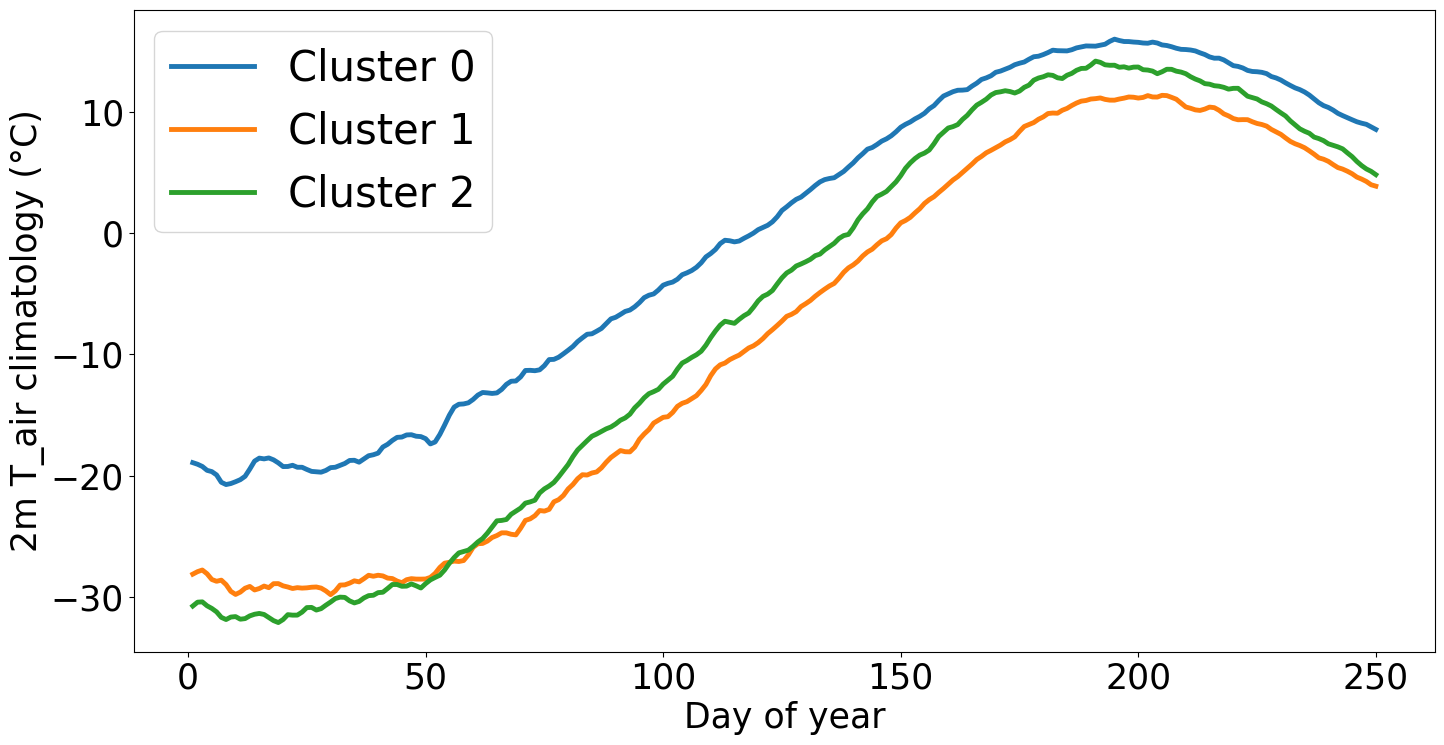

In [4]:
out_dir = "/home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land"

# Define the period
start_year, end_year = 1988, 2022
years = np.arange(start_year, end_year + 1)
ndoy = 250

# Define paths
Daily_ERA5_path = f"{data2_FP}/ERA5_Land/extracted_nc/Above_60N/Revised_ERA5_25km_60N"
TB_cluster_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc"

# 1. Load cluster map
with nc.Dataset(TB_cluster_path) as ds:
    TB_cluster = ds.variables["TB_cluster"][:]
TB_cluster = TB_cluster.astype(int)

cluster_ids = [0, 1, 2]
base_counts = {cid: int(np.sum(TB_cluster == cid)) for cid in cluster_ids}


# 2. Create the storage for climatologies
clim_tair = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}


# Diagnostics: per-year kept pixel counts and fractions (after seasonal_mask)
mask_counts = {cid: [] for cid in cluster_ids}
mask_fracs  = {cid: [] for cid in cluster_ids}

# Union seasonal mask (True if seasonal_mask True in ANY year)
seasonal_union = np.zeros_like(TB_cluster, dtype=bool)

# Precompute cluster masks
cluster_masks = {cid: (TB_cluster == cid) for cid in cluster_ids}


# 3. Loop over years
for yi, year in enumerate(years):
    path = f"{Daily_ERA5_path}/ERA5_Land_Daily_Above_60N_{year}.nc"
    with nc.Dataset(path) as ds:
        # SWE used only for seasonal mask in this code
        SWE  = ds.variables["sd_mean"][:, :, :ndoy]    # SWE (m w.e.)  (lat, lon, doy)
        Tair = ds.variables["t2m_mean"][:, :, :ndoy]   # air temperature (K) (lat, lon, doy)

    # Seasonal snow mask: keep pixels with near-zero summer SWE
    # DOY 200–230 -> indices 199:230
    summer_mean_swe = np.nanmean(SWE[:, :, 199:230], axis=2)
    seasonal_mask = (summer_mean_swe < 0.01)  # 0.01 m w.e. = 10 mm

    # Update union mask
    seasonal_union |= seasonal_mask

    # Diagnostics: per-year kept pixel counts and fractions (after seasonal_mask)
    for cid in cluster_ids:
        base = cluster_masks[cid]
        n_base = base_counts[cid]
        n_keep = int(np.sum(base & seasonal_mask))
        mask_counts[cid].append(n_keep)
        mask_fracs[cid].append(n_keep / n_base if n_base > 0 else np.nan)

    # Convert to °C once per year (float32 to save memory)
    Tair_C = (Tair.astype(np.float32) - 273.15)

    # Compute per-DOY spatial means within each cluster (with seasonal mask)
    for d in range(ndoy):
        t_d = Tair_C[:, :, d]
        for cid in cluster_ids:
            m = cluster_masks[cid] & seasonal_mask
            if np.any(m):
                clim_tair[cid][yi, d] = np.nanmean(t_d[m])
            else:
                clim_tair[cid][yi, d] = np.nan


# 4. Summaries
print("=== Seasonal-mask impact (per cluster) ===")
for cid in cluster_ids:
    print(f"Cluster {cid}: base pixels = {base_counts[cid]}")
    print(f"  kept pixels (mean ± std over years): "
          f"{np.mean(mask_counts[cid]):.0f} ± {np.std(mask_counts[cid]):.0f}")
    print(f"  kept fraction (mean ± std): "
          f"{np.mean(mask_fracs[cid])*100:.1f}% ± {np.std(mask_fracs[cid])*100:.1f}%")
    print(f"  union seasonal fraction (any year): "
          f"{np.mean(seasonal_union[cluster_masks[cid]])*100:.1f}%")

# 35-year mean climatologies (°C)
clim_tair_mean = {cid: np.nanmean(clim_tair[cid], axis=0) for cid in cluster_ids}

# Plot
doys = np.arange(1, ndoy + 1)

plt.rcParams.update({
    'font.size': 25,        
    'axes.titlesize': 30,     
    'axes.labelsize': 25,     
    'xtick.labelsize': 25,   
    'ytick.labelsize': 25,    
    'legend.fontsize': 30     
})


plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_tair_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("2m T_air climatology (°C)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Tair_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()